# Multiplicative miscalibration of logistic models — reproducible experiments

This notebook (R kernel) reproduces every computation, table and figure in `index.qmd`, in the order they appear in the paper:

| § | Experiment | Paper reference |
|---|---|---|
| 1 | Normal Q-Q plots of `Petal.Width` | `@fig-qq` |
| 2 | LDA vs. logistic regression on iris (max gap ≈ 0.14) | `@fig-chunk1` |
| 3 | Linear separation of setosa / virginica; summary table | `@tbl-petalwidth` |
| 4 | Order-statistics sample size for the ranges to intersect (n ≈ 464 000) | text |
| 5 | Table of scaling (label-smoothing) methods | `@tbl-prior-r` |
| 6 | Predictions of eight models on a single simulated dataset | `@fig-one-dataset-predictions` |
| 7 | Monte Carlo calibration ratios (M = 30) | `@fig-calibration-ratios` |
| 8 | Firth miscalibration vs. Cohen's *d* | `@fig-firth-dscan` |
| 9 | Speaker data: regularized LDA projection + assumption checks | Partial one-vs-one section |
| 10 | Partial Wu–Lin–Weng coupling, LDA vs. Firth (accuracy 0.94 → 0.62) | `@fig-partial-coupling` |
| 11 | Pairwise multiplicative miscalibration on test data | `@fig-miscal-box` |
| 12 | Ratio decomposition for the misclassified M points | `@eq-ratio3` |

**Requirements.** R packages `MASS`, `glmnet`, `logistf`, `arm` (plus `IRkernel` for the Jupyter kernel). Run the notebook from the project directory (`ams/`), which contains `data/embeddings_EN_clean.csv` and `data/embeddings_UN_clean.csv`.

In [1]:
## ---- Setup -----------------------------------------------------------------
suppressPackageStartupMessages({
  library(MASS)      # lda
  library(glmnet)    # L1 / L2 penalized logistic regression
  library(logistf)   # Firth logistic regression
  library(arm)       # bayesglm: Cauchy / Student-t priors
})

## If the notebook is not started from the project folder, point this at it.
# setwd("~/Desktop/ams")
stopifnot(file.exists("index.qmd"))

## Re-run the Monte Carlo simulations (Sections 7, 8) instead of reading the
## cached CSVs written by simulate_calibration_ratios.R / firth_dscan.R.
RUN_SIMULATIONS <- TRUE

options(repr.plot.res = 120)
sessionInfo()$R.version$version.string

[1] "R version 4.5.2 (2025-10-31)"

## 1. Normality of the iris `Petal.Width` (Fig. `fig-qq`)

For both versicolor and virginica the points fall close to the reference line, indicating approximately normal class-conditional distributions.

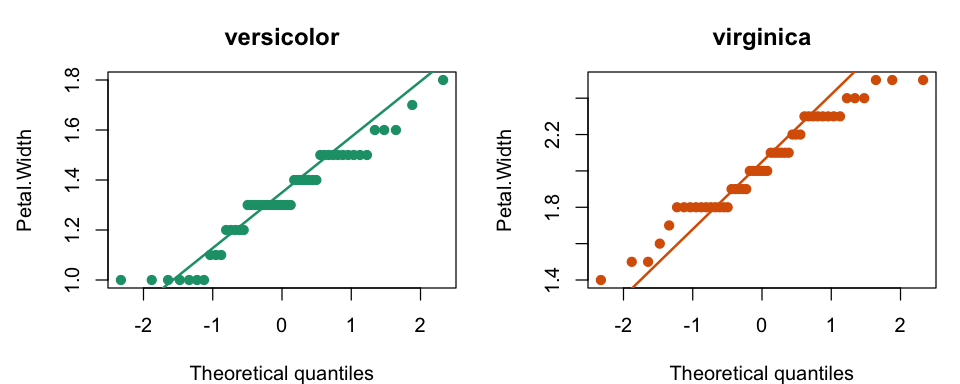

In [2]:
options(repr.plot.width = 8, repr.plot.height = 3.2)
d_qq <- droplevels(subset(iris, Species %in% c("versicolor", "virginica")))

col_versicolor <- "#1b9e77"
col_virginica  <- "#d95f02"

par(mfrow = c(1, 2), mar = c(4, 4.5, 3, 1))

pw_versicolor <- d_qq$Petal.Width[d_qq$Species == "versicolor"]
qqnorm(pw_versicolor, col = col_versicolor, pch = 19,
       main = "versicolor", xlab = "Theoretical quantiles",
       ylab = "Petal.Width")
qqline(pw_versicolor, col = col_versicolor, lwd = 2)

pw_virginica <- d_qq$Petal.Width[d_qq$Species == "virginica"]
qqnorm(pw_virginica, col = col_virginica, pch = 19,
       main = "virginica", xlab = "Theoretical quantiles",
       ylab = "Petal.Width")
qqline(pw_virginica, col = col_virginica, lwd = 2)

## 2. LDA vs. logistic regression on *Iris virginica* vs. *Iris versicolor* (Fig. `fig-chunk1`)

Both models give approximately equal predictions; the paper reports that the largest difference in predicted probabilities over the considered range is 0.14.

Maximal |p_LDA - p_logistic| over the grid: 0.140 at Petal.Width = 1.67


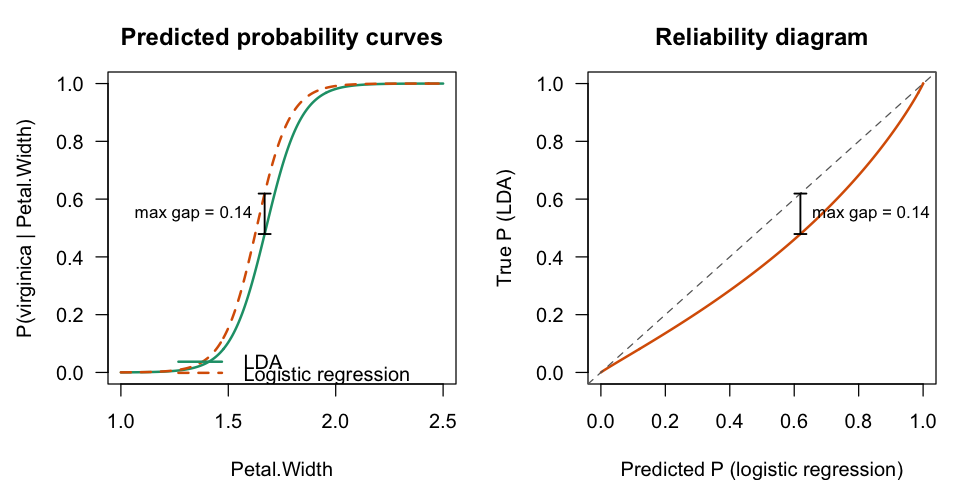

In [3]:
options(repr.plot.width = 8, repr.plot.height = 4)

d <- droplevels(subset(iris, Species %in% c("versicolor", "virginica")))
d$y <- as.integer(d$Species == "virginica")

lda_fit <- lda(Species ~ Petal.Width, data = d)
glm_fit <- glm(y ~ Petal.Width, data = d, family = binomial)

xg <- seq(min(d$Petal.Width), max(d$Petal.Width), length.out = 400)

p_lda <- predict(lda_fit, newdata = data.frame(Petal.Width = xg))$posterior[, "virginica"]
p_glm <- predict(glm_fit, newdata = data.frame(Petal.Width = xg), type = "response")

col_lda <- "#1b9e77"
col_glm <- "#d95f02"

par(mfrow = c(1, 2), mar = c(4, 4.5, 3, 1))
plot(xg, p_lda, type = "l", lwd = 2, col = col_lda, yaxt = "n",
     xlab = "Petal.Width", ylab = "P(virginica | Petal.Width)",
     main = "Predicted probability curves", ylim = c(0, 1))
lines(xg, p_glm, lwd = 2, lty = 2, col = col_glm)
y_ticks <- seq(0, 1, by = 0.2)
axis(2, at = y_ticks, labels = sprintf("%.1f", y_ticks), las = 1)

## Maximal gap between the two predicted curves ("dimension line").
gap <- abs(p_lda - p_glm)
i_max <- which.max(gap)
x_max <- xg[i_max]
y_lo <- min(p_lda[i_max], p_glm[i_max])
y_hi <- max(p_lda[i_max], p_glm[i_max])
arrows(x0 = x_max, y0 = y_lo, x1 = x_max, y1 = y_hi,
       code = 3, angle = 90, length = 0.05, lwd = 1.5, col = "black")
text(x_max, (y_lo + y_hi) / 2, sprintf("max gap = %.2f", gap[i_max]), pos = 2, cex = 0.85)
legend("bottomright", bty = "n", legend = c("LDA", "Logistic regression"),
       col = c(col_lda, col_glm), lwd = 2, lty = c(1, 2))

## Right panel: smooth reliability diagram, x -> (p_glm(x), p_lda(x)).
plot(p_glm, p_lda, type = "l", lwd = 2, col = col_glm,
     xlim = c(0, 1), ylim = c(0, 1), las = 1,
     xlab = "Predicted P (logistic regression)",
     ylab = "True P (LDA)", main = "Reliability diagram")
abline(0, 1, lty = 2, col = "grey40")
x0 <- p_glm[i_max]
arrows(x0 = x0, y0 = x0, x1 = x0, y1 = p_lda[i_max],
       code = 3, angle = 90, length = 0.05, lwd = 1.5, col = "black")
text(x0, (x0 + p_lda[i_max]) / 2, sprintf("max gap = %.2f", gap[i_max]), pos = 4, cex = 0.85)

cat(sprintf("Maximal |p_LDA - p_logistic| over the grid: %.3f at Petal.Width = %.2f\n",
            gap[i_max], x_max))

## 3. Linear separation: setosa vs. virginica (Table `tbl-petalwidth`)

The `Petal.Width` ranges of setosa and virginica do not intersect, so the maximum-likelihood logistic fit does not exist: `glm` reports fitted probabilities numerically 0 or 1 and the coefficients diverge.

In [4]:
species_levels <- levels(iris$Species)
petal_width_tab <- data.frame(
  Species = species_levels,
  Count = sapply(species_levels, function(s) sum(iris$Species == s)),
  Min   = sapply(species_levels, function(s) min(iris$Petal.Width[iris$Species == s])),
  Max   = sapply(species_levels, function(s) max(iris$Petal.Width[iris$Species == s])),
  Mean  = sapply(species_levels, function(s) mean(iris$Petal.Width[iris$Species == s])),
  SD    = sapply(species_levels, function(s) sd(iris$Petal.Width[iris$Species == s]))
)
rownames(petal_width_tab) <- NULL
print(petal_width_tab, digits = 3)

     Species Count Min Max  Mean    SD
1     setosa    50 0.1 0.6 0.246 0.105
2 versicolor    50 1.0 1.8 1.326 0.198
3  virginica    50 1.4 2.5 2.026 0.275


In [5]:
## Demonstration of non-convergence under separation.
d_sv <- droplevels(subset(iris, Species %in% c("setosa", "virginica")))
d_sv$y <- as.integer(d_sv$Species == "virginica")
cat("Separable (max setosa < min virginica):",
    max(d_sv$Petal.Width[d_sv$y == 0]) < min(d_sv$Petal.Width[d_sv$y == 1]), "\n")

glm_sv <- withCallingHandlers(
  glm(y ~ Petal.Width, data = d_sv, family = binomial),
  warning = function(w) { message("glm warning: ", conditionMessage(w)); invokeRestart("muffleWarning") })
print(coef(glm_sv))

## Log-likelihood along the ray w = lambda, b = -lambda approaches 0 (L -> 1).
for (lambda in c(1, 5, 10, 50))
  cat(sprintf("lambda = %3d   log L = %.3e\n", lambda,
              sum(dbinom(d_sv$y, 1, plogis(lambda * (d_sv$Petal.Width - 1)), log = TRUE))))

Separable (max setosa < min virginica): TRUE 


glm warning: glm.fit: algorithm did not converge

glm warning: glm.fit: fitted probabilities numerically 0 or 1 occurred



(Intercept) Petal.Width 
  -53.49470    53.46267 
lambda =   1   log L = -3.502e+01
lambda =   5   log L = -2.042e+00
lambda =  10   log L = -9.861e-02
lambda =  50   log L = -4.165e-09


## 4. How many samples until the ranges intersect?

With $n$ samples per class the setosa and virginica ranges fail to intersect when $\max_i X_i < \min_j Y_j$:
$$P\left(\max_i X_i < \min_j Y_j\right) = \int F_s(t)^n \; n\,\bigl(1-F_v(t)\bigr)^{n-1} f_v(t)\, dt.$$
We evaluate it on the log scale with the plug-in parameters (setosa $\mu=0.25,\ \sigma=0.11$; virginica $\mu=2.03,\ \sigma=0.27$) and solve for the $n$ at which it equals $1/2$. The paper reports $n \approx 464\,000$.

In [6]:
p_no_intersect <- function(n, ms, ss, mv, sv) {
  integrand <- function(t) exp(n * pnorm(t, ms, ss, log.p = TRUE) + log(n) +
                               (n - 1) * pnorm(t, mv, sv, lower.tail = FALSE, log.p = TRUE) +
                               dnorm(t, mv, sv, log = TRUE))
  integrate(integrand, ms, mv, subdivisions = 2000L, rel.tol = 1e-10)$value
}

pars <- c(ms = 0.25, ss = 0.11, mv = 2.03, sv = 0.27)
p_sep <- function(n) p_no_intersect(n, pars["ms"], pars["ss"], pars["mv"], pars["sv"])

cat(sprintf("P(no intersection) with n = 50 per class: %.7f\n", p_sep(50)))
n_half <- exp(uniroot(function(ln) p_sep(exp(ln)) - 0.5,
                      c(log(10), log(1e8)), tol = 1e-10)$root)
cat(sprintf("n per class at which P(no intersection) = 1/2: %.0f\n", n_half))

## Separation in pooled standard deviations
s_pooled <- sqrt((pars["ss"]^2 + pars["sv"]^2) / 2)
cat(sprintf("Mean difference in pooled SDs: %.2f\n", (pars["mv"] - pars["ms"]) / s_pooled))

P(no intersection) with n = 50 per class: 0.9999993
n per class at which P(no intersection) = 1/2: 463521
Mean difference in pooled SDs: 8.63


## 5. Scaling (label-smoothing) methods (Table `tbl-prior-r`)

In [7]:
prior_tab <- data.frame(
  Prior       = c("Laplace (uniform)", "Jeffreys"),
  Beta_prior  = c("Beta(1, 1)", "Beta(1/2, 1/2)"),
  R           = c("N + 1", "2N + 1"),
  Method_name = c("Platt scaling", "SAH scaling")
)
print(prior_tab, right = FALSE)

  Prior             Beta_prior     R      Method_name  
1 Laplace (uniform) Beta(1, 1)     N + 1  Platt scaling
2 Jeffreys          Beta(1/2, 1/2) 2N + 1 SAH scaling  


## 6. Eight models on one simulated dataset (Fig. `fig-one-dataset-predictions`)

50 samples per class from $N(0,1)$ and $N(6,1)$; `set.seed(1)` reproduces the first replication of the Monte Carlo study in Section 7.

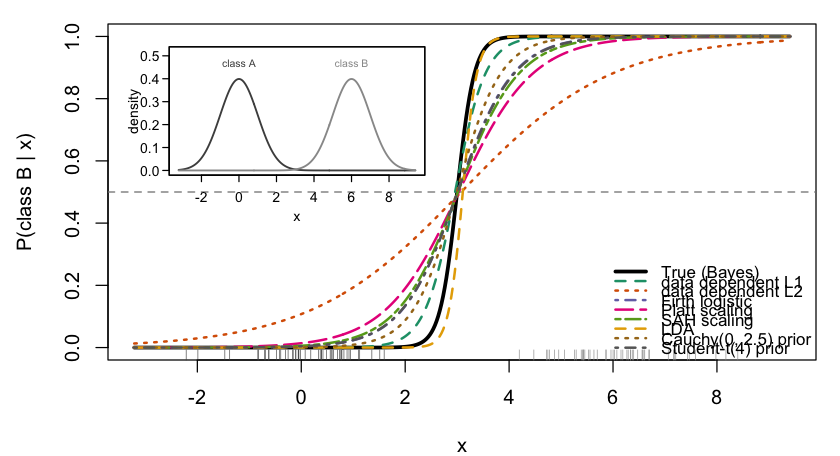

In [8]:
options(repr.plot.width = 7, repr.plot.height = 3.8)

set.seed(1)
n   <- 50
mu1 <- 0; mu2 <- 6; sdv <- 1

x1 <- rnorm(n, mu1, sdv)
x2 <- rnorm(n, mu2, sdv)
x  <- c(x1, x2)
y  <- factor(rep(c("A", "B"), each = n))
yb <- as.integer(y == "B")

xg <- seq(min(x) - 1, max(x) + 1, length.out = 400)

## True Bayes-optimal probability.
b_true <- (mu2 - mu1) / sdv^2
a_true <- -(mu2^2 - mu1^2) / (2 * sdv^2)
p_true <- plogis(a_true + b_true * xg)

## L1 / L2 penalized logistic regression (cross-validated lambda).
x_mean <- mean(x); x_sd <- sd(x)
X  <- cbind((x  - x_mean) / x_sd, 0)
Xg <- cbind((xg - x_mean) / x_sd, 0)
cv_l2 <- cv.glmnet(X, y, family = "binomial", alpha = 0, standardize = FALSE)
cv_l1 <- cv.glmnet(X, y, family = "binomial", alpha = 1, standardize = FALSE)
p_l2 <- as.numeric(predict(cv_l2, newx = Xg, s = "lambda.min", type = "response"))
p_l1 <- as.numeric(predict(cv_l1, newx = Xg, s = "lambda.min", type = "response"))

## Firth logistic regression.
firth_fit <- logistf(yb ~ x, pl = FALSE)
p_firth <- plogis(coef(firth_fit)[1] + coef(firth_fit)[2] * xg)

## Platt scaling and SAH scaling (2N targets).
Np <- sum(yb == 1); Nn <- sum(yb == 0)
t_std <- ifelse(yb == 1, (Np + 1) / (Np + 2), 1 / (Nn + 2))
t_2N  <- ifelse(yb == 1, (2 * Np + 1) / (2 * Np + 2), 1 / (2 * Nn + 2))
p_platt  <- predict(suppressWarnings(glm(t_std ~ x, family = binomial)),
                    newdata = data.frame(x = xg), type = "response")
p_platt2 <- predict(suppressWarnings(glm(t_2N ~ x, family = binomial)),
                    newdata = data.frame(x = xg), type = "response")

## LDA (pooled-variance closed form).
m1 <- mean(x1); m2 <- mean(x2)
s2_pooled <- ((n - 1) * var(x1) + (n - 1) * var(x2)) / (2 * n - 2)
b_lda <- (m2 - m1) / s2_pooled
a_lda <- -(m2^2 - m1^2) / (2 * s2_pooled)
p_lda <- plogis(a_lda + b_lda * xg)

## Bayesian logistic regression (posterior mode), Cauchy(0, 2.5) and t_4 priors.
cauchy_fit <- bayesglm(yb ~ x, family = binomial,
                       prior.scale = 2.5, prior.df = 1,
                       prior.scale.for.intercept = 10, prior.df.for.intercept = 1)
p_cauchy <- plogis(coef(cauchy_fit)[1] + coef(cauchy_fit)[2] * xg)
t_fit <- bayesglm(yb ~ x, family = binomial,
                  prior.scale = 2.5, prior.df = 4,
                  prior.scale.for.intercept = 10, prior.df.for.intercept = 4)
p_t <- plogis(coef(t_fit)[1] + coef(t_fit)[2] * xg)

curves <- list(L1 = p_l1, L2 = p_l2, Firth = p_firth,
               Platt = p_platt, Platt_2N = p_platt2, LDA = p_lda,
               Cauchy = p_cauchy, StudentT = p_t)
cols <- c(L1 = "#1b9e77", L2 = "#d95f02", Firth = "#7570b3",
          Platt = "#e7298a", Platt_2N = "#66a61e", LDA = "#e6ab02",
          Cauchy = "#a6761d", StudentT = "#666666")
ltys <- c(L1 = 2, L2 = 3, Firth = 4, Platt = 5, Platt_2N = 6, LDA = 2,
          Cauchy = 3, StudentT = 4)
labs <- c(L1 = "data dependent L1", L2 = "data dependent L2", Firth = "Firth logistic",
          Platt = "Platt scaling", Platt_2N = "SAH scaling", LDA = "LDA",
          Cauchy = "Cauchy(0, 2.5) prior", StudentT = "Student-t(4) prior")

par(mar = c(4, 4.5, 1, 1))
plot(xg, p_true, type = "l", lwd = 3, col = "black",
     xlab = "x", ylab = "P(class B | x)", ylim = c(0, 1))
abline(h = 0.5, col = "grey50", lwd = 1, lty = 2)
for (mdl in names(curves)) lines(xg, curves[[mdl]], lwd = 2, col = cols[mdl], lty = ltys[mdl])
rug(x1, col = "grey30")
rug(x2, col = "grey60")

leg_args <- list(bty = "n", cex = 0.85,
                 legend = c("True (Bayes)", unname(labs[names(curves)])),
                 col = c("black", unname(cols[names(curves)])),
                 lwd = c(3, rep(2, length(curves))),
                 lty = c(1, unname(ltys[names(curves)])))
leg_probe <- do.call(legend, c(list("bottomright", plot = FALSE), leg_args))
line_h <- strheight("A", cex = 0.85)
do.call(legend, c(list(x = leg_probe$rect$left, y = leg_probe$rect$top + 0.5 * line_h), leg_args))

## Inset: class-conditional densities.
col_A <- "grey30"; col_B <- "grey60"
d_true_A <- dnorm(xg, mu1, sdv); d_true_B <- dnorm(xg, mu2, sdv)
peak_h <- max(d_true_A, d_true_B)
ip <- par(fig = c(0.13, 0.52, 0.50, 0.95), new = TRUE,
          mar = c(2.2, 2.5, 1, 0.5), cex = 0.7)
plot.new()
rect(0, 0, 1, 1, col = "white", border = NA, xpd = TRUE)
par(new = TRUE)
plot(xg, d_true_A, type = "l", lwd = 1.5, col = col_A,
     xlab = "", ylab = "", ylim = c(0, peak_h * 1.3), xaxt = "n", yaxt = "n")
lines(xg, d_true_B, lwd = 1.5, col = col_B)
axis(1, tck = -0.05, mgp = c(0, 0.3, 0))
axis(2, tck = -0.05, mgp = c(0, 0.4, 0), las = 1)
title(xlab = "x", ylab = "density", mgp = c(1.1, 0, 0))
box()
text(mu1, dnorm(mu1, mu1, sdv), "class A", col = col_A, cex = 0.75, pos = 3)
text(mu2, dnorm(mu2, mu2, sdv), "class B", col = col_B, cex = 0.75, pos = 3)
par(ip)

## 7. Monte Carlo calibration ratios (Fig. `fig-calibration-ratios`)

This is `simulate_calibration_ratios.R` inlined: M = 30 replications, 50 points per class from $N(0,1)$ and $N(6,1)$, eight models, and for every sampled point the ratio $\log_{10}(\hat p / p_{\text{true}})$ of the predicted to the true probability of class B. Everything is computed on the log scale via `plogis(eta, log.p = TRUE)`, so no clamping is needed. With `RUN_SIMULATIONS <- FALSE` the cached `calibration_ratios.csv` is read instead.

The paper reports that all logistic variants overestimate by more than five orders of magnitude on average, except data-dependent L1 (mean ≈ 1.5) and the Cauchy prior (mean ≈ 4.3).

In [9]:
simulate_calibration_ratios <- function(n_reps = 30, n = 50, mu1 = 0, mu2 = 6, sdv = 1) {
  ln10 <- log(10)
  fit_one_rep <- function(rep_id) {
    x1 <- rnorm(n, mu1, sdv); x2 <- rnorm(n, mu2, sdv)
    x  <- c(x1, x2)
    y  <- factor(rep(c("A", "B"), each = n))
    yb <- as.integer(y == "B")

    b_true <- (mu2 - mu1) / sdv^2
    a_true <- -(mu2^2 - mu1^2) / (2 * sdv^2)
    log_p_true <- plogis(a_true + b_true * x, log.p = TRUE)
    separable <- (max(x1) < min(x2)) || (max(x2) < min(x1))

    X <- cbind((x - mean(x)) / sd(x), 0)
    cv_l2 <- cv.glmnet(X, y, family = "binomial", alpha = 0, standardize = FALSE)
    cv_l1 <- cv.glmnet(X, y, family = "binomial", alpha = 1, standardize = FALSE)
    eta_l2 <- as.numeric(predict(cv_l2, newx = X, s = "lambda.min", type = "link"))
    eta_l1 <- as.numeric(predict(cv_l1, newx = X, s = "lambda.min", type = "link"))

    firth_fit <- logistf(yb ~ x, pl = FALSE)
    eta_firth <- coef(firth_fit)[1] + coef(firth_fit)[2] * x

    Np <- sum(yb == 1); Nn <- sum(yb == 0)
    t_std <- ifelse(yb == 1, (Np + 1) / (Np + 2), 1 / (Nn + 2))
    t_2N  <- ifelse(yb == 1, (2 * Np + 1) / (2 * Np + 2), 1 / (2 * Nn + 2))
    eta_platt  <- predict(suppressWarnings(glm(t_std ~ x, family = binomial)), type = "link")
    eta_platt2 <- predict(suppressWarnings(glm(t_2N ~ x, family = binomial)), type = "link")

    m1 <- mean(x1); m2 <- mean(x2)
    s2_pooled <- ((n - 1) * var(x1) + (n - 1) * var(x2)) / (2 * n - 2)
    eta_lda <- -(m2^2 - m1^2) / (2 * s2_pooled) + (m2 - m1) / s2_pooled * x

    cauchy_fit <- bayesglm(yb ~ x, family = binomial,
                           prior.scale = 2.5, prior.df = 1,
                           prior.scale.for.intercept = 10, prior.df.for.intercept = 1)
    eta_cauchy <- coef(cauchy_fit)[1] + coef(cauchy_fit)[2] * x
    t_fit <- bayesglm(yb ~ x, family = binomial,
                      prior.scale = 2.5, prior.df = 4,
                      prior.scale.for.intercept = 10, prior.df.for.intercept = 4)
    eta_t <- coef(t_fit)[1] + coef(t_fit)[2] * x

    etas <- list(L1 = eta_l1, L2 = eta_l2, Firth = eta_firth,
                 Platt = eta_platt, Platt_2N = eta_platt2, LDA = eta_lda,
                 Cauchy = eta_cauchy, StudentT = eta_t)
    do.call(rbind, lapply(names(etas), function(model_name) {
      log_p_hat <- plogis(etas[[model_name]], log.p = TRUE)
      data.frame(rep = rep_id, point_id = seq_along(x), class = as.character(y), x = x,
                 model = model_name, log_p_true = log_p_true, log_p_hat = log_p_hat,
                 log10_ratio = (log_p_hat - log_p_true) / ln10, separable = separable)
    }))
  }
  do.call(rbind, lapply(seq_len(n_reps), fit_one_rep))
}

if (RUN_SIMULATIONS) {
  set.seed(1)
  ratios_df <- simulate_calibration_ratios()
} else {
  ratios_df <- read.csv("calibration_ratios.csv")
}
M_reps <- length(unique(ratios_df$rep))
cat(sprintf("%d rows, M = %d replications, %.0f%% of replications linearly separable\n",
            nrow(ratios_df), M_reps,
            100 * mean(tapply(ratios_df$separable, ratios_df$rep, `[`, 1))))

24000 rows, M = 30 replications, 100% of replications linearly separable


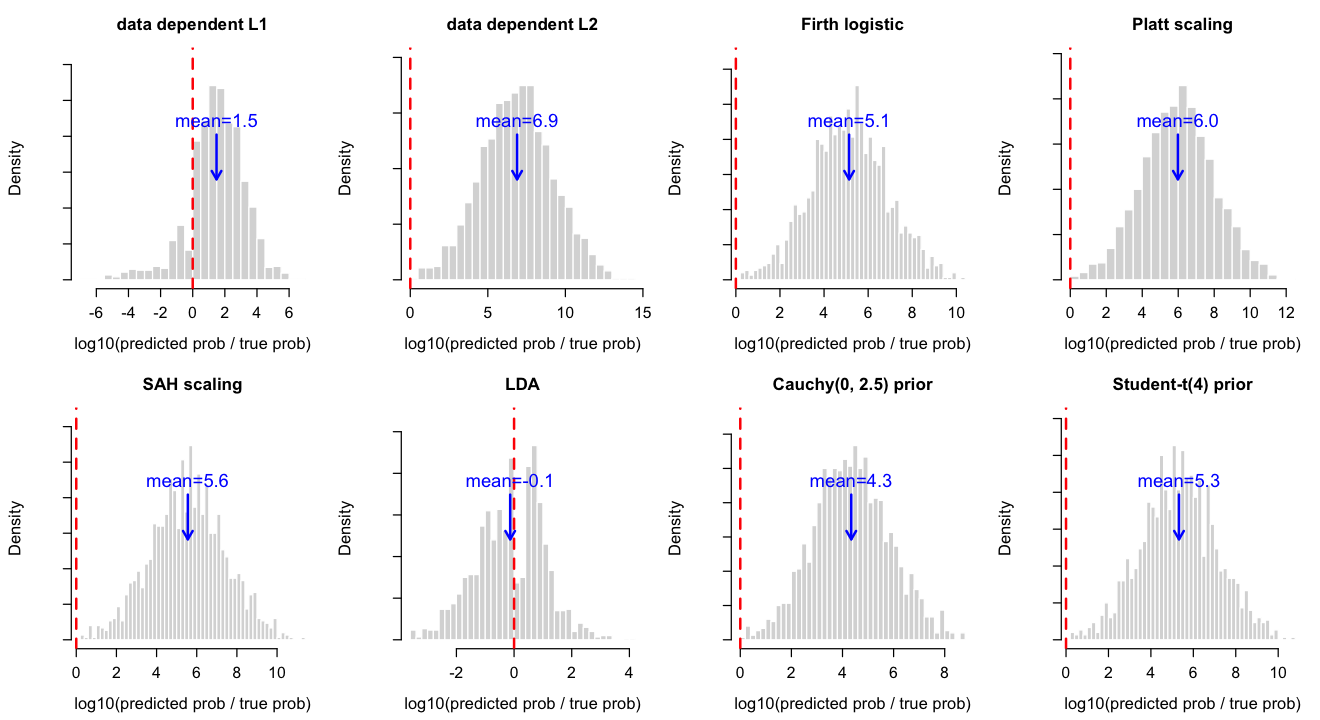

In [10]:
options(repr.plot.width = 11, repr.plot.height = 6)

model_order  <- c("L1", "L2", "Firth", "Platt", "Platt_2N", "LDA", "Cauchy", "StudentT")
model_labels <- labs

par(mfrow = c(2, 4), mar = c(4.5, 4.5, 3, 1),
    cex.axis = 1.2, cex.lab = 1.25, cex.main = 1.3)
for (m in model_order) {
  log_ratio <- ratios_df$log10_ratio[ratios_df$model == m & ratios_df$class == "A"]
  h <- hist(log_ratio, breaks = 40, plot = FALSE)
  ymax <- max(h$density) * 1.15
  hist(log_ratio, breaks = h$breaks, freq = FALSE, col = "grey85", border = "white",
       xlab = "log10(predicted prob / true prob)", ylab = "Density", ylim = c(0, ymax),
       main = unname(model_labels[m]), yaxt = "n")
  axis(2, labels = FALSE)
  abline(v = 0, col = "red", lwd = 2, lty = 2)
  m_val <- mean(log_ratio)
  arrows(x0 = m_val, y0 = ymax * 0.65, x1 = m_val, y1 = ymax * 0.45,
         col = "blue", lwd = 2, length = 0.08)
  text(m_val, ymax * 0.65, sprintf("mean=%.1f", m_val), col = "blue", pos = 3, cex = 1.4)
}

In [11]:
## Summary table of the class-A log10 ratios.
A <- ratios_df[ratios_df$class == "A", ]
summ <- do.call(rbind, lapply(model_order, function(m) {
  v <- A$log10_ratio[A$model == m]
  data.frame(model = unname(model_labels[m]), mean = mean(v), median = median(v),
             sd = sd(v), min = min(v), max = max(v))
}))
print(summ, digits = 3, row.names = FALSE)

                model   mean  median   sd     min   max
    data dependent L1  1.483  1.5820 1.76 -6.8984  6.50
    data dependent L2  6.888  6.9085 2.32  0.3165 14.13
       Firth logistic  5.137  5.1194 1.73  0.2365 10.39
        Platt scaling  5.983  6.0193 1.99  0.2602 12.15
          SAH scaling  5.557  5.5914 1.85  0.2434 11.25
                  LDA -0.135 -0.0871 1.20 -3.5739  4.18
 Cauchy(0, 2.5) prior  4.343  4.3268 1.50  0.0753  8.78
   Student-t(4) prior  5.324  5.3399 1.77  0.2366 10.75


## 8. Firth miscalibration as a function of Cohen's *d* (Fig. `fig-firth-dscan`)

`firth_dscan.R` inlined: for each $d \in [1, 8]$ (step 0.25), 100 datasets of 50 points per class from $N(0,1)$ and $N(d,1)$; Firth logistic regression is fitted (modified-score IRLS) and $\log_{10}(\hat p/p_{\text{true}})$ of class B is evaluated at the mode of class A ($x=0$), where $p_{\text{true}} = \sigma(-d^2/2)$. Miscalibration is negligible up to $d \approx 3.5$ and takes off where samples of this size become frequently separable.

In [12]:
firth_logistic_1d <- function(x, y, tol = 1e-8, max_iter = 100) {
  X <- cbind(1, x)
  beta <- c(0, 0)
  for (i in 1:max_iter) {
    eta  <- as.vector(X %*% beta)
    p    <- plogis(eta)
    W    <- p * (1 - p)
    XtWX <- t(X) %*% (X * W)
    XtWX_inv <- solve(XtWX)
    h <- W * rowSums((X %*% XtWX_inv) * X)
    U_star <- t(X) %*% (y - p + h * (0.5 - p))
    step <- as.vector(XtWX_inv %*% U_star)
    beta <- beta + step
    if (max(abs(step)) < tol) break
  }
  beta
}

if (RUN_SIMULATIONS) {
  set.seed(1)
  n_reps_d <- 100; n_d <- 50; d_grid <- seq(1, 8, by = 0.25); ln10 <- log(10)
  dscan <- do.call(rbind, lapply(d_grid, function(d) {
    per_rep <- vapply(seq_len(n_reps_d), function(rep_id) {
      xx <- c(rnorm(n_d, 0, 1), rnorm(n_d, d, 1))
      yy <- rep(c(0, 1), each = n_d)
      beta <- firth_logistic_1d(xx, yy)
      log_p_hat  <- plogis(beta[1], log.p = TRUE)
      log_p_true <- plogis(-d^2 / 2, log.p = TRUE)
      c(ratio = (log_p_hat - log_p_true) / ln10, log_or = beta[2])
    }, c(ratio = 0, log_or = 0))
    data.frame(d = d,
               mean_log10_ratio = mean(per_rep["ratio", ]),
               sd_log10_ratio   = sd(per_rep["ratio", ]),
               mean_log10_or    = mean(per_rep["log_or", ]) / ln10,
               true_log10_or    = d / ln10)
  }))
} else {
  dscan <- read.csv("firth_dscan.csv")
}
print(dscan[dscan$d %% 1 == 0, ], digits = 3, row.names = FALSE)

 d mean_log10_ratio sd_log10_ratio mean_log10_or true_log10_or
 1          0.00393          0.042         0.425         0.434
 2          0.03919          0.157         0.828         0.869
 3         -0.05981          0.783         1.350         1.303
 4          0.34905          1.647         1.570         1.737
 5          2.33817          0.613         1.229         2.171
 6          5.07902          0.293         0.903         2.606
 7          8.17275          0.177         0.711         3.040
 8         11.58219          0.123         0.583         3.474


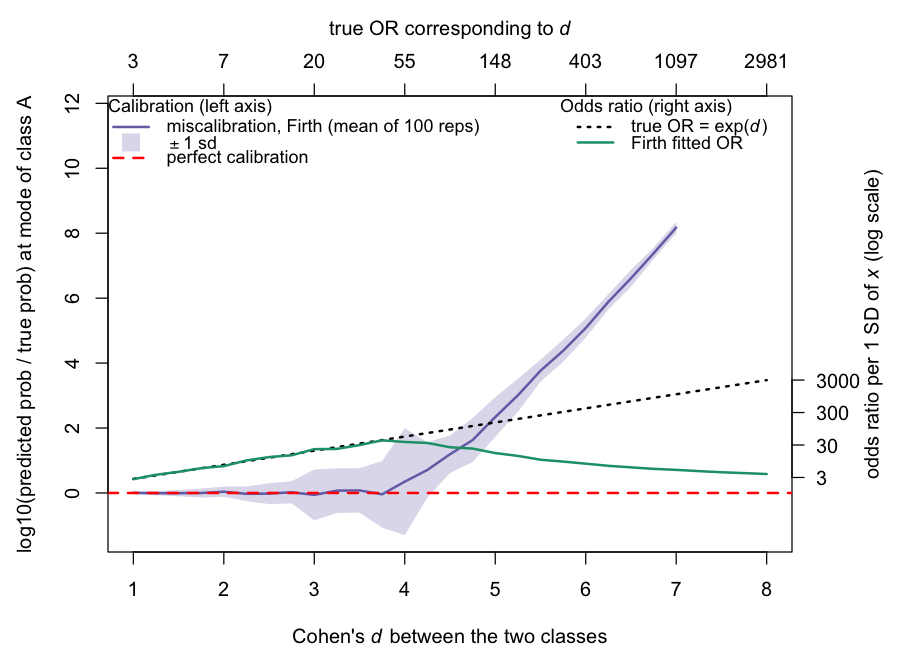

In [13]:
options(repr.plot.width = 7.5, repr.plot.height = 5.5)
res <- dscan
par(mar = c(4.5, 4.5, 4, 4.5))
ylim <- range(res$mean_log10_ratio - res$sd_log10_ratio,
              res$mean_log10_ratio + res$sd_log10_ratio, 0, res$true_log10_or)
plot(res$d, res$mean_log10_ratio, type = "n", ylim = ylim,
     xlab = expression("Cohen's " * italic(d) * " between the two classes"),
     ylab = "log10(predicted prob / true prob) at mode of class A")
shown <- res$d <= 7.2
polygon(c(res$d[shown], rev(res$d[shown])),
        c((res$mean_log10_ratio - res$sd_log10_ratio)[shown],
          rev((res$mean_log10_ratio + res$sd_log10_ratio)[shown])),
        col = adjustcolor("#7570b3", alpha.f = 0.25), border = NA)
lines(res$d[shown], res$mean_log10_ratio[shown], lwd = 2, col = "#7570b3")
abline(h = 0, col = "red", lwd = 2, lty = 2)

lines(res$d, res$true_log10_or, lwd = 2, lty = 3, col = "black")
lines(res$d, res$mean_log10_or, lwd = 2, col = "#1b9e77")
axis(4, at = log10(c(3, 30, 300, 3000)), labels = c("3", "30", "300", "3000"), las = 1)
mtext(expression("odds ratio per 1 SD of " * italic(x) * " (log scale)"), side = 4, line = 3)
axis(3, at = 1:8, labels = sprintf("%.0f", exp(1:8)))
mtext(expression("true OR corresponding to " * italic(d)), side = 3, line = 2.2)

legend("topleft", bty = "n", cex = 0.9,
       title = "Calibration (left axis)", title.adj = 0,
       legend = c("miscalibration, Firth (mean of 100 reps)", expression("" %+-% "1 sd"),
                  "perfect calibration"),
       col = c("#7570b3", adjustcolor("#7570b3", alpha.f = 0.25), "red"),
       lty = c(1, NA, 2), lwd = c(2, NA, 2), pch = c(NA, 15, NA), pt.cex = c(NA, 2, NA))
legend("topright", bty = "n", cex = 0.9,
       title = "Odds ratio (right axis)", title.adj = 0,
       legend = c(expression("true OR = exp(" * italic(d) * ")"), "Firth fitted OR"),
       col = c("black", "#1b9e77"), lty = c(3, 1), lwd = c(2, 2))

## 9. Speaker-recognition data: projection and assumption checks

Training: English recordings (201 segments, 67/speaker); test: Urdu recordings (195 segments, 65/speaker). Each row is a unit-norm 192-dim ECAPA-TDNN embedding. The CSVs are read directly; regenerating them from `recordings/` requires Python (torch, torchaudio, speechbrain, soundfile) via `data_preparation.R`.

The 192-dim embeddings are reduced to $K-1=2$ canonical directions with regularized LDA (shrinkage $\gamma = 0.5$), fitted on the training set only and whitened so the training pooled within-class covariance is spherical.

In [14]:
tr <- read.csv("data/embeddings_EN_clean.csv")   # training: English
te <- read.csv("data/embeddings_UN_clean.csv")   # test:     Urdu

spk <- sort(unique(tr$speaker))                  # "A" "M" "S"
Xtr192 <- as.matrix(tr[, -1]); ytr <- factor(tr$speaker, levels = spk)
Xte192 <- as.matrix(te[, -1]); yte <- factor(te$speaker, levels = spk)
p192 <- ncol(Xtr192); K3 <- 3
cat("train:", nrow(Xtr192), "x", p192, " per speaker:", table(ytr), "\n")
cat("test: ", nrow(Xte192), "x", ncol(Xte192), " per speaker:", table(yte), "\n")

## Regularized LDA projection 192 -> 2, fitted on the training data only.
alpha3 <- 0.5
nk3    <- as.integer(table(ytr))
mu192  <- t(sapply(spk, function(k) colMeans(Xtr192[ytr == k, ])))
Sw192  <- Reduce(`+`, lapply(1:K3, function(i)
            (nk3[i] - 1) * cov(Xtr192[ytr == spk[i], ]))) / (nrow(Xtr192) - K3)
Sw192  <- (1 - alpha3) * Sw192 + alpha3 * mean(diag(Sw192)) * diag(p192)
ew192  <- eigen(Sw192, symmetric = TRUE)
Wh192  <- ew192$vectors %*% diag(1 / sqrt(pmax(ew192$values, 1e-12))) %*% t(ew192$vectors)
V2     <- eigen(cov(mu192 %*% Wh192) * (K3 - 1), symmetric = TRUE)$vectors[, 1:2]
P2     <- Wh192 %*% V2

Ztr <- Xtr192 %*% P2; Zte <- Xte192 %*% P2
means3 <- t(sapply(spk, function(k) colMeans(Ztr[ytr == k, ])))
dimnames(means3) <- list(spk, c("x", "y"))

dat3  <- data.frame(x = Ztr[, 1], y = Ztr[, 2], class = ytr)   # training
test3 <- data.frame(x = Zte[, 1], y = Zte[, 2], class = yte)   # test
means3

train: 201 x 192  per speaker: 67 67 67 
test:  195 x 192  per speaker: 65 65 65 


,x,y
A,0.7834174,-4.0922252
M,3.5268845,1.7568685
S,-4.5357133,0.6310575


### Assumption checks (`assumption_checks.R`)

1. Bivariate normality within each speaker — Royston's multivariate Shapiro–Wilk test.
2. Equal covariances across speakers — Box's $M$ test.
3. Separation — Cohen's $d$ (Mahalanobis distance). The paper reports $d$ = 7.07, 8.29, 9.20 (English) and 5.92, 6.85, 8.26 (Urdu) for A–M, A–S, M–S, and perfect linear separability of all pairs.

In [15]:
royston_H <- function(X) {
  X <- as.matrix(X); n <- nrow(X); p <- ncol(X)
  if (n < 12 || n > 2000) stop("royston_H is implemented for 12 <= n <= 2000")
  kurt <- function(v) { m <- mean(v); mean((v - m)^4) / mean((v - m)^2)^2 }
  sf_W <- function(v) cor(sort(v), qnorm(ppoints(length(v), a = 3/8)))^2
  lx <- log(n)
  mu <- -1.5861 - 0.31082 * lx - 0.083751 * lx^2 + 0.0038915 * lx^3
  sg <- exp(-0.4803 - 0.082676 * lx + 0.0030302 * lx^2)
  z <- vapply(seq_len(p), function(i) {
    v <- X[, i]
    W <- if (kurt(v) > 3) sf_W(v) else as.numeric(shapiro.test(v)$statistic)
    (log(1 - W) - mu) / sg
  }, numeric(1))
  u <- 0.715; v <- 0.21364 + 0.015124 * lx^2 - 0.0018034 * lx^3; l <- 5
  C  <- cor(X)
  NC <- (C^l) * (1 - (u * (1 - C)^u) / v)
  mC  <- (sum(NC) - p) / (p^2 - p)
  edf <- p / (1 + (p - 1) * mC)
  H   <- edf * sum(qnorm(pnorm(-z) / 2)^2) / p
  c(H = H, p.value = pchisq(H, df = edf, lower.tail = FALSE))
}

box_M <- function(Z, g) {
  lv <- levels(droplevels(as.factor(g)))
  gq <- length(lv); m <- nrow(Z); q <- ncol(Z)
  ni <- as.integer(table(g)[lv])
  Si <- lapply(lv, function(k) cov(Z[g == k, , drop = FALSE]))
  Sp <- Reduce(`+`, Map(function(S, a) (a - 1) * S, Si, ni)) / (m - gq)
  M  <- (m - gq) * log(det(Sp)) - sum((ni - 1) * sapply(Si, function(S) log(det(S))))
  c1 <- (sum(1 / (ni - 1)) - 1 / (m - gq)) * (2 * q^2 + 3 * q - 1) / (6 * (q + 1) * (gq - 1))
  df <- (gq - 1) * q * (q + 1) / 2
  c(chisq = M * (1 - c1), df = df, p.value = pchisq(M * (1 - c1), df, lower.tail = FALSE))
}

cohens_d <- function(Z, g, a, b) {
  i <- g == a; j <- g == b; k <- ncol(Z); n1 <- sum(i); n2 <- sum(j)
  S  <- ((n1 - 1) * cov(Z[i, ]) + (n2 - 1) * cov(Z[j, ])) / (n1 + n2 - 2)
  dm <- colMeans(Z[i, ]) - colMeans(Z[j, ])
  d2 <- as.numeric(t(dm) %*% solve(S) %*% dm)
  c(raw = sqrt(d2),
    adj = sqrt(max((n1 + n2 - k - 3) / (n1 + n2 - 2) * d2 - k * (1/n1 + 1/n2), 0)))
}

## Linear separability of a pair: a hard-margin check via LP-free perceptron-style
## test using the (unregularized) logistic fit -- a separable pair drives the
## fitted probabilities to 0/1 and classifies every training point correctly.
separable_pair <- function(Z, g, a, b) {
  idx <- g %in% c(a, b)
  yy <- as.integer(g[idx] == b)
  fit <- suppressWarnings(glm(yy ~ Z[idx, ], family = binomial))
  all((fitted(fit) > 0.5) == (yy == 1))
}

cells <- list(list(lab = "english (training)", Z = Ztr, g = ytr),
              list(lab = "urdu (test)",        Z = Zte, g = yte))

cat("===== 1. Royston's multivariate Shapiro-Wilk, per speaker =====\n")
for (cl in cells) for (k in spk) {
  r <- royston_H(cl$Z[cl$g == k, ])
  cat(sprintf("%-20s %-3s n = %3d   H = %7.3f   p = %.4f\n", cl$lab, k,
              sum(cl$g == k), r["H"], r["p.value"]))
}
cat("\n===== 2. Box's M for equality of the three covariances =====\n")
for (cl in cells) {
  b <- box_M(cl$Z, cl$g)
  cat(sprintf("%-20s chi-sq = %7.3f   df = %d   p = %.4f\n", cl$lab,
              b["chisq"], as.integer(b["df"]), b["p.value"]))
}
cat("\n===== 3. Cohen's d and linear separability between speakers =====\n")
for (cl in cells) for (pr in combn(spk, 2, simplify = FALSE)) {
  d <- cohens_d(cl$Z, cl$g, pr[1], pr[2])
  cat(sprintf("%-20s %s-%s   d = %5.2f   corrected = %5.2f   separable = %s\n",
              cl$lab, pr[1], pr[2], d["raw"], d["adj"],
              separable_pair(cl$Z, cl$g, pr[1], pr[2])))
}

===== 1. Royston's multivariate Shapiro-Wilk, per speaker =====
english (training)   A   n =  67   H =   0.546   p = 0.7612
english (training)   M   n =  67   H =   2.092   p = 0.3515
english (training)   S   n =  67   H =   0.493   p = 0.7815
urdu (test)          A   n =  65   H =   1.821   p = 0.4023
urdu (test)          M   n =  65   H =   0.454   p = 0.7970
urdu (test)          S   n =  65   H =   0.733   p = 0.6933

===== 2. Box's M for equality of the three covariances =====
english (training)   chi-sq =   6.700   df = 6   p = 0.3495
urdu (test)          chi-sq =   5.464   df = 6   p = 0.4858

===== 3. Cohen's d and linear separability between speakers =====
english (training)   A-M   d =  7.07   corrected =  6.98   separable = TRUE
english (training)   A-S   d =  8.29   corrected =  8.19   separable = TRUE
english (training)   M-S   d =  9.20   corrected =  9.09   separable = TRUE
urdu (test)          A-M   d =  4.04   corrected =  3.98   separable = FALSE
urdu (test)          A

## 10. Partial Wu–Lin–Weng coupling (Fig. `fig-partial-coupling`)

One-vs-one base classifiers: LDA (closed-form pooled covariance) and Firth logistic regression (modified-score IRLS). With pair $(i,j)$ dropped, the coupled probabilities have the closed form $p_i:p_j:p_k = e^{\eta_{ik}} : e^{\eta_{jk}} : 1$, evaluated from raw log-odds so nothing saturates. Test (Urdu) points are plotted; crosses are the training centroids defining the plug-in Bayes (nearest-mean) boundary.

In [16]:
pairs3 <- combn(3, 2, simplify = FALSE)   # (1,2) (1,3) (2,3) indexing spk

## LDA pairwise fits, evaluated as raw linear scores.
lda_pair_coef <- list()
for (pr in pairs3) {
  lo <- pr[1]; hi <- pr[2]
  Xlo <- as.matrix(dat3[as.integer(dat3$class) == lo, c("x", "y")])
  Xhi <- as.matrix(dat3[as.integer(dat3$class) == hi, c("x", "y")])
  n_lo <- nrow(Xlo); n_hi <- nrow(Xhi)
  mlo <- colMeans(Xlo); mhi <- colMeans(Xhi)
  Sigma <- ((n_lo - 1) * cov(Xlo) + (n_hi - 1) * cov(Xhi)) / (n_lo + n_hi - 2)
  Sinv  <- solve(Sigma)
  w <- as.numeric(Sinv %*% (mhi - mlo))
  b <- -0.5 * as.numeric(mhi %*% Sinv %*% mhi - mlo %*% Sinv %*% mlo) + log(n_hi / n_lo)
  lda_pair_coef[[paste0(lo, "_", hi)]] <- list(w = w, b = b)
}
lda_eta_pair_raw <- function(lo, hi, Xnew) {
  cf <- lda_pair_coef[[paste0(lo, "_", hi)]]
  as.numeric(Xnew %*% cf$w + cf$b)
}

## Firth pairwise fits (modified-score IRLS).
firth_logistic3 <- function(X, y, tol = 1e-8, max_iter = 50) {
  X <- cbind(Intercept = 1, X)
  beta <- rep(0, ncol(X))
  for (i in 1:max_iter) {
    eta  <- as.vector(X %*% beta)
    p_i  <- plogis(eta)
    W    <- p_i * (1 - p_i)
    XtWX <- t(X) %*% (X * W)
    XtWX_inv <- solve(XtWX)
    h <- W * rowSums((X %*% XtWX_inv) * X)
    U_star <- t(X) %*% (y - p_i + h * (0.5 - p_i))
    step <- as.vector(XtWX_inv %*% U_star)
    beta <- beta + step
    if (max(abs(step)) < tol) break
  }
  list(beta = beta)
}
firth_pair_fits <- list()
for (pr in pairs3) {
  lo <- pr[1]; hi <- pr[2]
  sub <- dat3[as.integer(dat3$class) %in% c(lo, hi), ]
  firth_pair_fits[[paste0(lo, "_", hi)]] <-
    firth_logistic3(as.matrix(sub[, c("x", "y")]), as.integer(as.integer(sub$class) == hi))
}
firth_eta_pair_raw <- function(lo, hi, Xnew) {
  as.numeric(cbind(1, Xnew) %*% firth_pair_fits[[paste0(lo, "_", hi)]]$beta)
}

## Signed log-odds of class a over class b.
make_log_odds <- function(eta_pair_raw) {
  function(a, b, Xnew) {
    lo <- min(a, b); hi <- max(a, b)
    eta <- eta_pair_raw(lo, hi, Xnew)
    if (a == hi) eta else -eta
  }
}
lda_log_odds   <- make_log_odds(lda_eta_pair_raw)
firth_log_odds <- make_log_odds(firth_eta_pair_raw)

## Closed-form partial WLW coupling.
couple_predict_partial <- function(Xnew, i, j, k, log_odds_fn) {
  L <- matrix(0, nrow(Xnew), 3)
  L[, i] <- log_odds_fn(i, k, Xnew); L[, j] <- log_odds_fn(j, k, Xnew); L[, k] <- 0
  w <- exp(L - apply(L, 1, max))
  w / rowSums(w)
}

## Full (3-term) WLW coupling via the Wu-Lin-Weng (2004) fixed-point iteration.
wlw_couple <- function(r, max_iter = 200, eps = 0.005 / nrow(r)) {
  k <- nrow(r)
  Q <- matrix(0, k, k)
  for (pr in combn(k, 2, simplify = FALSE)) {
    a <- pr[1]; b <- pr[2]
    Q[a, a] <- Q[a, a] + r[b, a]^2
    Q[b, b] <- Q[b, b] + r[a, b]^2
    Q[a, b] <- Q[a, b] - r[b, a] * r[a, b]
    Q[b, a] <- Q[b, a] - r[a, b] * r[b, a]
  }
  p <- rep(1 / k, k)
  for (iter in 1:max_iter) {
    Qp  <- as.vector(Q %*% p); pQp <- sum(p * Qp)
    if (max(abs(Qp - pQp)) < eps) break
    for (t in 1:k) {
      diff <- (-Qp[t] + pQp) / Q[t, t]
      p[t] <- p[t] + diff
      pQp  <- (pQp + diff * (diff * Q[t, t] + 2 * Qp[t])) / (1 + diff)^2
      Qp   <- (Qp + diff * Q[t, ]) / (1 + diff)
      p    <- p / (1 + diff)
    }
  }
  p / sum(p)
}
couple_predict_full <- function(Xnew, log_odds_fn) {
  ## r[a, b] = P(a | a or b)
  R <- lapply(1:3, function(a) lapply(1:3, function(b)
         if (a == b) rep(0, nrow(Xnew)) else plogis(log_odds_fn(a, b, Xnew))))
  t(sapply(seq_len(nrow(Xnew)), function(row) {
    r <- matrix(0, 3, 3)
    for (a in 1:3) for (b in 1:3) r[a, b] <- R[[a]][[b]][row]
    wlw_couple(r)
  }))
}

## Plug-in Bayes (nearest estimated mean in the sphered plane).
bayes_predict3 <- function(Xnew) {
  D <- sapply(1:3, function(k) rowSums((Xnew - matrix(means3[k, ], nrow(Xnew), 2, byrow = TRUE))^2))
  logf <- -0.5 * D
  ex <- exp(logf - apply(logf, 1, max))
  ex / rowSums(ex)
}

drops <- list(drop12 = c(i = 1, j = 2, k = 3),
              drop13 = c(i = 1, j = 3, k = 2),
              drop23 = c(i = 2, j = 3, k = 1))
drop_titles <- c(drop12 = sprintf("drop pair (%s,%s)", spk[1], spk[2]),
                 drop13 = sprintf("drop pair (%s,%s)", spk[1], spk[3]),
                 drop23 = sprintf("drop pair (%s,%s)", spk[2], spk[3]))

In [17]:
## Held-out (Urdu) accuracy: plug-in Bayes, full WLW and each partial coupling.
Xte2  <- as.matrix(test3[, c("x", "y")])
truth <- as.integer(test3$class)
acc   <- function(P) mean(max.col(P) == truth)

acc_tab <- data.frame(
  coupling = c("plug-in Bayes (nearest mean)", "full WLW (3 terms)", unname(drop_titles)),
  LDA   = c(acc(bayes_predict3(Xte2)), acc(couple_predict_full(Xte2, lda_log_odds)),
            sapply(drops, function(d) acc(couple_predict_partial(Xte2, d["i"], d["j"], d["k"], lda_log_odds)))),
  Firth = c(NA, acc(couple_predict_full(Xte2, firth_log_odds)),
            sapply(drops, function(d) acc(couple_predict_partial(Xte2, d["i"], d["j"], d["k"], firth_log_odds))))
)
print(acc_tab, digits = 3, row.names = FALSE)

                     coupling   LDA Firth
 plug-in Bayes (nearest mean) 0.954    NA
           full WLW (3 terms) 0.954 0.944
              drop pair (A,M) 0.954 0.615
              drop pair (A,S) 0.959 0.954
              drop pair (M,S) 0.954 0.856


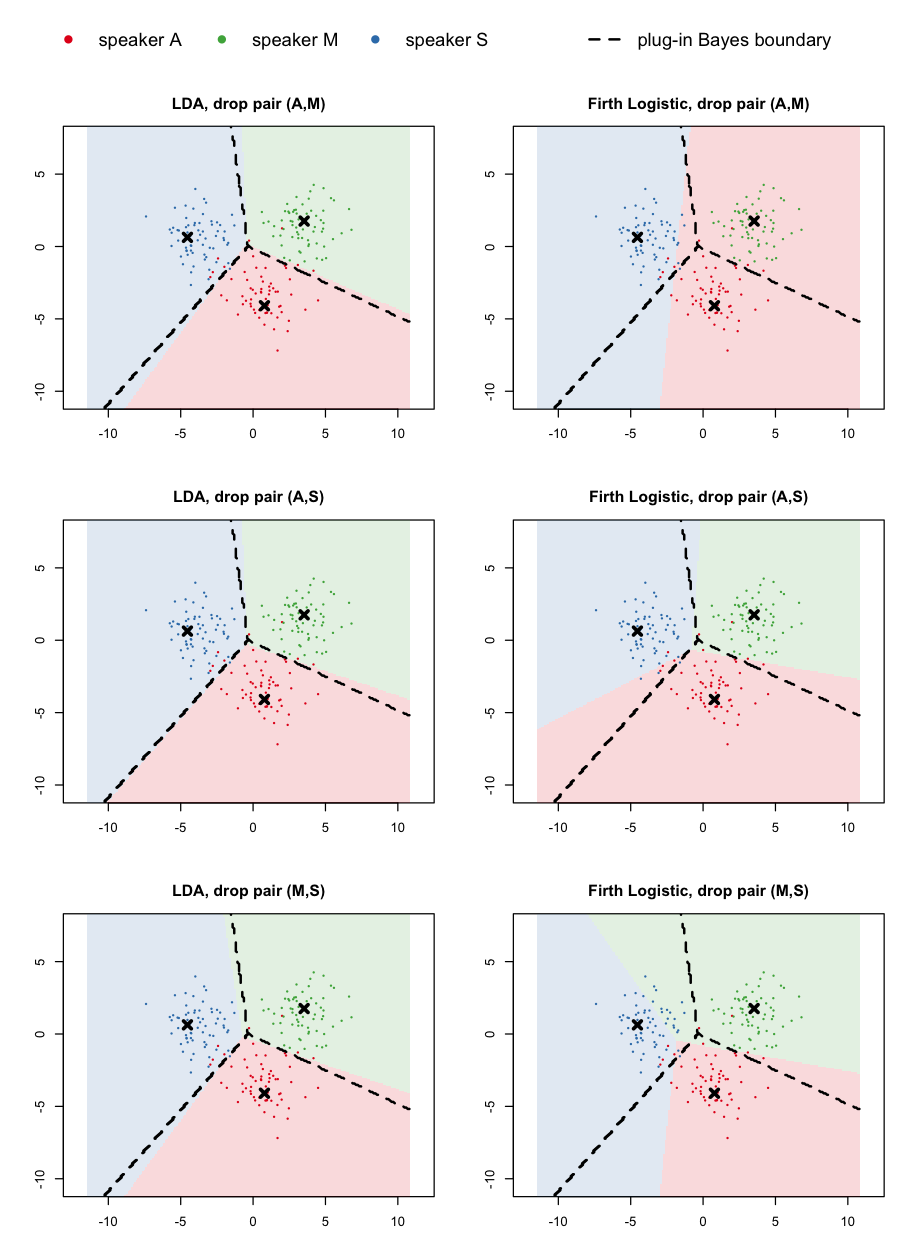

In [18]:
options(repr.plot.width = 7.5, repr.plot.height = 10.5)

margin3 <- 4
allxy <- rbind(as.matrix(dat3[, c("x", "y")]), as.matrix(test3[, c("x", "y")]), means3)
gx3 <- seq(min(allxy[, 1]) - margin3, max(allxy[, 1]) + margin3, length.out = 200)
gy3 <- seq(min(allxy[, 2]) - margin3, max(allxy[, 2]) + margin3, length.out = 200)
grid3 <- expand.grid(x = gx3, y = gy3)
Xg3 <- as.matrix(grid3)
nx3 <- length(gx3); ny3 <- length(gy3)
grid3$pred_bayes <- max.col(bayes_predict3(Xg3))

class_cols3 <- c("#e41a1c", "#4daf4a", "#377eb8")

add_bayes_boundary3 <- function() {
  contour(gx3, gy3, matrix(grid3$pred_bayes, nx3, ny3), levels = c(1.5, 2.5),
          add = TRUE, drawlabels = FALSE, lwd = 2, lty = 2, col = "black")
}
plot_argmax_panel <- function(pred_col, title) {
  image(gx3, gy3, matrix(pred_col, nx3, ny3),
        col = adjustcolor(class_cols3, alpha.f = 0.15), breaks = c(0.5, 1.5, 2.5, 3.5),
        xlab = "", ylab = "", asp = 1, main = title)
  points(test3$x, test3$y, col = class_cols3[as.integer(test3$class)], pch = 16, cex = 0.4)
  points(means3[, 1], means3[, 2], pch = 4, lwd = 3, cex = 1.3)
  add_bayes_boundary3()
}

layout(matrix(c(1, 1, 2, 3, 4, 5, 6, 7), nrow = 4, byrow = TRUE),
       heights = c(0.6, 3, 3, 3))
par(mar = c(0, 0, 0, 0))
plot.new()
legend("center", bty = "n", cex = 1.4, horiz = TRUE,
       legend = c(paste("speaker", spk), "", "plug-in Bayes boundary"),
       col = c(class_cols3, NA, "black"), pch = c(16, 16, 16, NA, NA),
       lty = c(NA, NA, NA, NA, 2), lwd = 2, seg.len = 2, x.intersp = 0.7,
       text.width = c(rep(0.12, 3), 0.03, 0.25))

par(mar = c(4, 4, 3, 1))
for (dn in names(drops)) {
  d <- drops[[dn]]
  pred_lda   <- max.col(couple_predict_partial(Xg3, d["i"], d["j"], d["k"], lda_log_odds))
  pred_firth <- max.col(couple_predict_partial(Xg3, d["i"], d["j"], d["k"], firth_log_odds))
  plot_argmax_panel(pred_lda,   paste0("LDA, ", drop_titles[dn]))
  plot_argmax_panel(pred_firth, paste0("Firth Logistic, ", drop_titles[dn]))
}
layout(1)

## 11. Pairwise multiplicative miscalibration on the test set (Fig. `fig-miscal-box`)

For each pair $(i,j)$, only held-out points whose true speaker is $i$ are used (so $j$ is the less likely class), and $\log_{10}(p_{\text{Firth}}/p_{\text{LDA}})$ is computed with LDA as the reference.

        A-M  A-S  M-S
median 6.52 10.2 15.7
mean   6.61 10.3 16.0


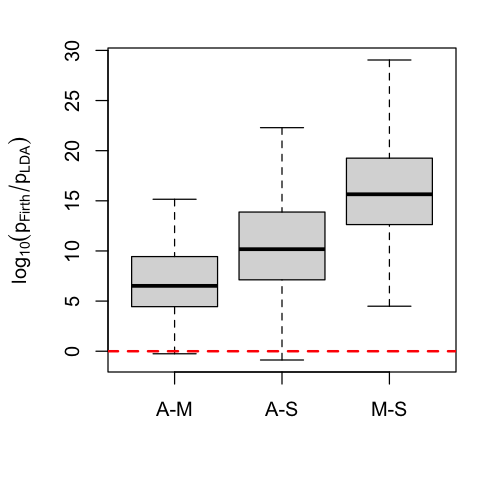

In [19]:
options(repr.plot.width = 4, repr.plot.height = 4)

miscal <- list()
for (pr in pairs3) {
  lo <- pr[1]; hi <- pr[2]; key <- paste0(lo, "_", hi)
  Xte_lo <- Xte2[truth == lo, , drop = FALSE]
  ## log10 of p(class hi), computed on the log scale (no clamping at 1e-300).
  miscal[[key]] <- (plogis(firth_eta_pair_raw(lo, hi, Xte_lo), log.p = TRUE) -
                    plogis(lda_eta_pair_raw(lo, hi, Xte_lo),   log.p = TRUE)) / log(10)
}

par(mar = c(4.5, 4.5, 2, 1))
boxplot(miscal[["1_2"]], miscal[["1_3"]], miscal[["2_3"]],
        names = c("A-M", "A-S", "M-S"), col = "grey85",
        ylab = expression(log[10](p[Firth] / p[LDA])))
abline(h = 0, col = "red", lwd = 2, lty = 2)

print(sapply(setNames(miscal, c("A-M", "A-S", "M-S")),
             function(v) c(median = median(v), mean = mean(v))), digits = 3)

## 12. Ratio decomposition for the misclassified M points (`eq-ratio3`)

Held-out M points that the drop-$(A,M)$ Firth coupling classifies as A. With the A–M classifier removed, $p(A)/p(M) = \frac{p(A)}{p(S)}\cdot\frac{p(S)}{p(M)}$, so the result depends on how the A–S and M–S classifiers each estimate $p(S)$. The paper reports median $\log_{10}(p_{\text{Firth}}/p_{\text{LDA}})$ of 6.05 (A–S) and 15.65 (M–S).

*Note:* `index.qmd` clamps probabilities at `1e-300` before taking logs; if $p_{\text{LDA}}$ underflows below that, the clamped value differs from the exact log-scale value computed here. Both are printed.

In [20]:
X_M <- Xte2[truth == 2, , drop = FALSE]
pred_dropAM <- max.col(couple_predict_partial(X_M, i = 1, j = 2, k = 3, firth_log_odds))
X_bad <- X_M[pred_dropAM == 1, , drop = FALSE]   # true M, predicted A
cat("Held-out M points misclassified as A by drop-(A,M) Firth coupling:", nrow(X_bad), "\n\n")

## Exact log-scale version.
log10_ratio_S <- function(lo) (plogis(firth_eta_pair_raw(lo, 3, X_bad), log.p = TRUE) -
                               plogis(lda_eta_pair_raw(lo, 3, X_bad),   log.p = TRUE)) / log(10)
mis_AS <- median(log10_ratio_S(1)); mis_MS <- median(log10_ratio_S(2))

## Version with the 1e-300 clamp used in index.qmd.
clamped <- function(lo) median(log10(pmax(plogis(firth_eta_pair_raw(lo, 3, X_bad)), 1e-300)) -
                               log10(pmax(plogis(lda_eta_pair_raw(lo, 3, X_bad)),   1e-300)))

print(data.frame(classifier = c("A-S", "M-S", "difference (M-S minus A-S)"),
                 median_log10_exact   = c(mis_AS, mis_MS, mis_MS - mis_AS),
                 median_log10_clamped = c(clamped(1), clamped(2), clamped(2) - clamped(1))),
      digits = 4, row.names = FALSE)

Held-out M points misclassified as A by drop-(A,M) Firth coupling: 65 

                 classifier median_log10_exact median_log10_clamped
                        A-S              6.051                6.051
                        M-S             15.652               15.652
 difference (M-S minus A-S)              9.601                9.601


---
Section *Out-of-distribution detection* in the paper is discussion only and has no associated computation.

In [21]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sonoma 14.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C

time zone: Europe/Bratislava
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] arm_1.15-3     lme4_1.1-38    logistf_1.26.1 glmnet_4.1-10  Matrix_1.7-4  
[6] MASS_7.3-65   

loaded via a namespace (and not attached):
 [1] generics_0.1.4         tidyr_1.3.1            shape_1.4.6.1         
 [4] lattice_0.22-7         digest_0.6.39          magrittr_2.0.4        
 [7] mitml_0.4-5            evaluate_1.0.5         grid_4.5.2            
[10] pbdZMQ_0.3-14          iterators_1.0.14       mice_3.19.0           
[13] fastmap